# Histogram / Box Plot of Media Sentiment and Impact

Insight on some less talked about conflicts: Myanmar and Burkina Faso

- Visualization
    - Histogram / box plot
    - Use GDELT avg_tone / avg_impact (Goldstein)
- Questions
    - What does the global media sentiment and impact say about these conflicts?

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

In [94]:
gdelt_path = "../data/GDELT/"
try:
	# prefer fastparquet to avoid pyarrow extension type errors
	df_keys = pd.read_parquet(gdelt_path + "gdelt_keys.parquet", engine="fastparquet")
	df_impact = pd.read_parquet(gdelt_path + "gdelt_impact.parquet", engine="fastparquet")
	df_tone = pd.read_parquet(gdelt_path + "gdelt_sentiment.parquet", engine="fastparquet")
	df_mention = pd.read_parquet(gdelt_path + "gdelt_volume_metrics.parquet", engine="fastparquet")
except Exception:
	# fallback to pyarrow if needed
	df_keys = pd.read_parquet(gdelt_path + "gdelt_keys.parquet", engine="pyarrow")
	df_impact = pd.read_parquet(gdelt_path + "gdelt_impact.parquet", engine="pyarrow")
	df_tone = pd.read_parquet(gdelt_path + "gdelt_sentiment.parquet", engine="pyarrow")
	df_mention = pd.read_parquet(gdelt_path + "gdelt_volume_metrics.parquet", engine="pyarrow")

In [95]:
df_keys.head()

,conflict_id,mention_week,conflict_country,actor1_country,actor2_country,media_country
0,0,2026-01-12,UK,UNK,GBR,UP
1,1,2026-01-12,FR,FRA,USA,US
2,2,2026-01-12,IS,GBR,UNK,UK
3,3,2026-01-12,UP,EUR,RUS,UK
4,4,2026-01-12,EZ,SVK,UNK,EZ


In [96]:
df_impact.head()

,conflict_id,avg_impact,stddev_impact,median_impact
0,0,-6.337500,3.286919,-7.2
1,1,-5.360396,2.004599,-5.0
2,2,-3.687500,2.463121,-2.0
3,3,-2.052885,0.591478,-2.0
4,4,-3.750000,2.752272,-2.0


In [97]:
df_tone.head()

,conflict_id,avg_tone,stddev_tone,median_tone
0,0,-2.480499,2.584627,-2.956522
1,1,-2.311362,3.035549,-0.337079
2,2,-5.187022,3.175163,-4.311774
3,3,-4.748191,0.274187,-4.770318
4,4,-5.115266,2.634168,-6.008584


In [98]:
df_mention.head()

,conflict_id,mentions_count,distinct_events,distinct_media_sources
0,0,16,13,11
1,1,101,28,71
2,2,8,8,5
3,3,208,5,105
4,4,6,5,4


In [99]:
# Join the dataframes on a common key 'conflict_id'
df_merged = df_keys.merge(df_impact, on='conflict_id').merge(df_tone, on='conflict_id').merge(df_mention, on='conflict_id')
df_merged.head()

,conflict_id,mention_week,conflict_country,actor1_country,actor2_country,media_country,avg_impact,stddev_impact,median_impact,avg_tone,stddev_tone,median_tone,mentions_count,distinct_events,distinct_media_sources
0,0,2026-01-12,UK,UNK,GBR,UP,-6.337500,3.286919,-7.2,-2.480499,2.584627,-2.956522,16,13,11
1,1,2026-01-12,FR,FRA,USA,US,-5.360396,2.004599,-5.0,-2.311362,3.035549,-0.337079,101,28,71
2,2,2026-01-12,IS,GBR,UNK,UK,-3.687500,2.463121,-2.0,-5.187022,3.175163,-4.311774,8,8,5
3,3,2026-01-12,UP,EUR,RUS,UK,-2.052885,0.591478,-2.0,-4.748191,0.274187,-4.770318,208,5,105
4,4,2026-01-12,EZ,SVK,UNK,EZ,-3.750000,2.752272,-2.0,-5.115266,2.634168,-6.008584,6,5,4


In [100]:
# Filter for Myanmar (FIPS code 'BM') related conflicts from 2021 onwards
df_myanmar = df_merged[(df_merged['conflict_country'] == 'BM') & (df_merged['mention_week'] >= '2021-01-01')]
# Keep only relevant columns: 'mention_week', 'median_tone', 'median_impact', 'mentions_count'
df_myanmar = df_myanmar[['mention_week', 'median_tone', 'median_impact', 'mentions_count']]
df_myanmar.head()

,mention_week,median_tone,median_impact,mentions_count
629,2026-01-12,-4.746835,-9.5,12
829,2026-01-12,-5.126602,-5.0,13
2473,2026-01-12,-0.223214,-9.2,9
3943,2026-01-12,-10.576923,-10.0,8
3945,2026-01-12,-9.949833,-5.0,16


In [101]:
# Burkina Faso Analysis
# Filter for Burkina Faso (FIPS code 'UV') related conflicts from 2021 onwards
df_burkina = df_merged[(df_merged['conflict_country'] == 'UV') & (df_merged['mention_week'] >= '2021-01-01')]
# Keep only relevant columns: 'mention_week', 'median_tone', 'median_impact', 'mentions_count'
df_burkina = df_burkina[['mention_week', 'median_tone', 'median_impact', 'mentions_count']]
df_burkina.head()

,mention_week,median_tone,median_impact,mentions_count
5026,2026-01-12,-6.666667,-10.0,11
5141,2026-01-12,-1.498929,-5.0,6
10194,2026-01-12,-6.666667,-10.0,8
10747,2026-01-05,-5.497382,-4.4,19
13881,2026-01-05,-8.582090,-10.0,6


In [102]:
# Palestine Analysis
# Filter for Palestine (FIPS code 'WE' and 'GZ') related conflicts from 2021 onwards
df_palestine = df_merged[(df_merged['conflict_country'].isin(['WE', 'GZ'])) & (df_merged['mention_week'] >= '2021-01-01')]
# Keep only relevant columns: 'mention_week', 'median_tone', 'median_impact', 'mentions_count'
df_palestine = df_palestine[['mention_week', 'median_tone', 'median_impact', 'mentions_count']]
df_palestine.head()


,mention_week,median_tone,median_impact,mentions_count
31,2026-01-12,-7.222222,-10.0,7
157,2026-01-12,-6.716418,-10.0,10
171,2026-01-12,-6.956522,-10.0,12
318,2026-01-12,-5.680120,-10.0,12
460,2026-01-12,-4.140127,-10.0,13


In [103]:
# Italy Analysis
# Filter for Italy (FIPS code 'IT') related conflicts
df_italy = df_merged[(df_merged['conflict_country'] == 'IT') & (df_merged['mention_week'] >= '2021-01-01')]
# Keep only relevant columns: 'mention_week', 'median_tone', 'median_impact', 'mentions_count'
df_italy = df_italy[['mention_week', 'median_tone', 'median_impact', 'mentions_count']]

# Clear df_italy from unvalid data
df_italy['median_impact'] = pd.to_numeric(df_italy['median_impact'], errors='coerce')
df_italy = df_italy.dropna(subset=['median_impact'])
df_italy.head()


,mention_week,median_tone,median_impact,mentions_count
30,2026-01-12,0.502513,-5.0,7
201,2026-01-12,-2.727981,-5.0,30
414,2026-01-12,-3.493450,-5.0,488
438,2026-01-12,-5.027548,-5.0,11
525,2026-01-12,3.523810,-2.0,26


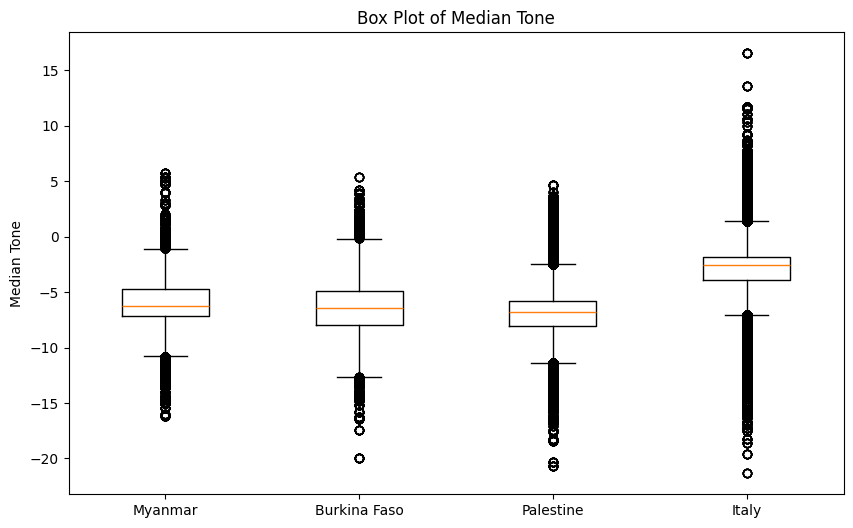

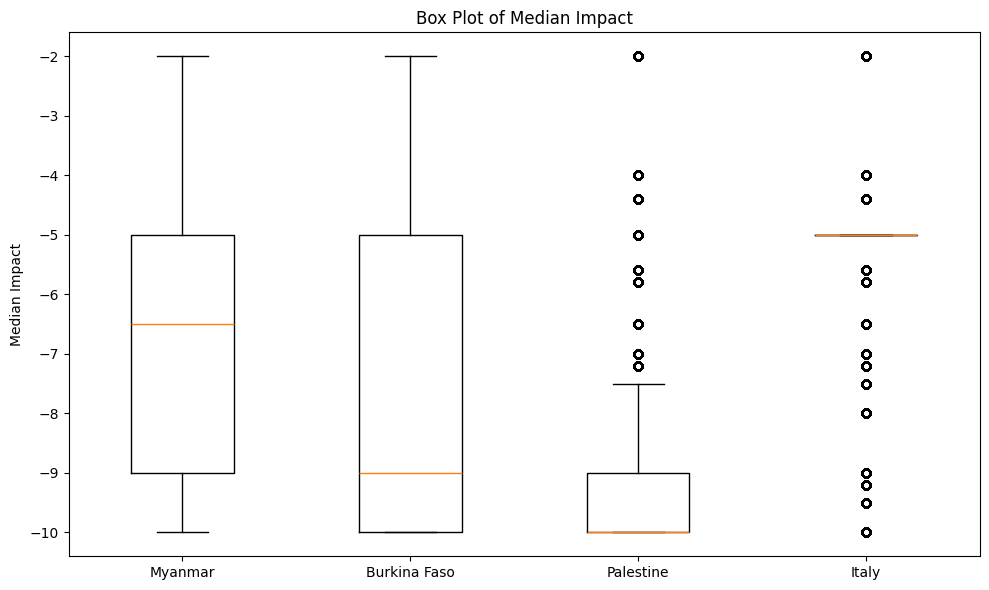

In [104]:
# Box plots for median_tone and median_impact weighted by mentions_count of Myanmar, Burkina Faso, Palestine, USA
plt.figure(figsize=(10, 6))
# Tone Box Plot
plt.title('Box Plot of Median Tone')
plt.ylabel('Median Tone')
plt.boxplot([df_myanmar['median_tone'].repeat(df_myanmar['mentions_count']),
             df_burkina['median_tone'].repeat(df_burkina['mentions_count']),
             df_palestine['median_tone'].repeat(df_palestine['mentions_count']),
             df_italy['median_tone'].repeat(df_italy['mentions_count'])],
             tick_labels=['Myanmar', 'Burkina Faso', 'Palestine', 'Italy'])
# Impact Box Plot
plt.figure(figsize=(10, 6))
plt.title('Box Plot of Median Impact')
plt.ylabel('Median Impact')
plt.boxplot([df_myanmar['median_impact'].repeat(df_myanmar['mentions_count']),
             df_burkina['median_impact'].repeat(df_burkina['mentions_count']),
             df_palestine['median_impact'].repeat(df_palestine['mentions_count']),
             df_italy['median_impact'].repeat(df_italy['mentions_count'])],
             tick_labels=['Myanmar', 'Burkina Faso', 'Palestine', 'Italy'])
plt.tight_layout()
plt.show()

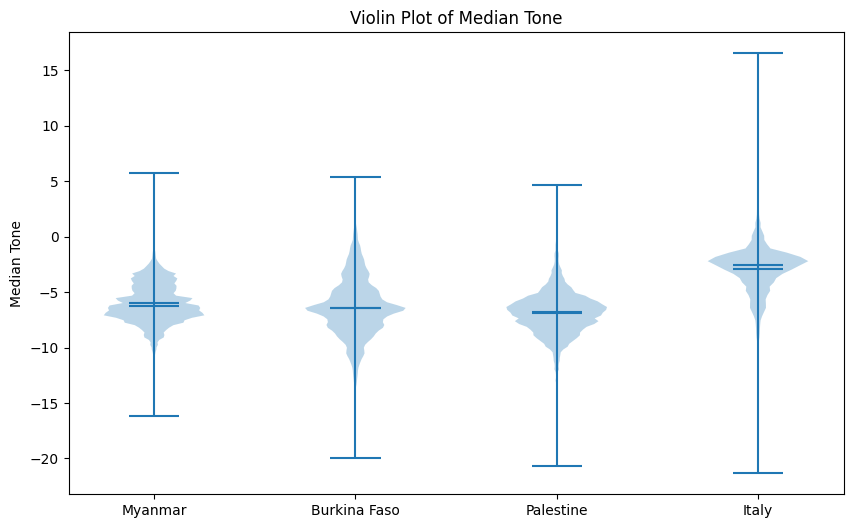

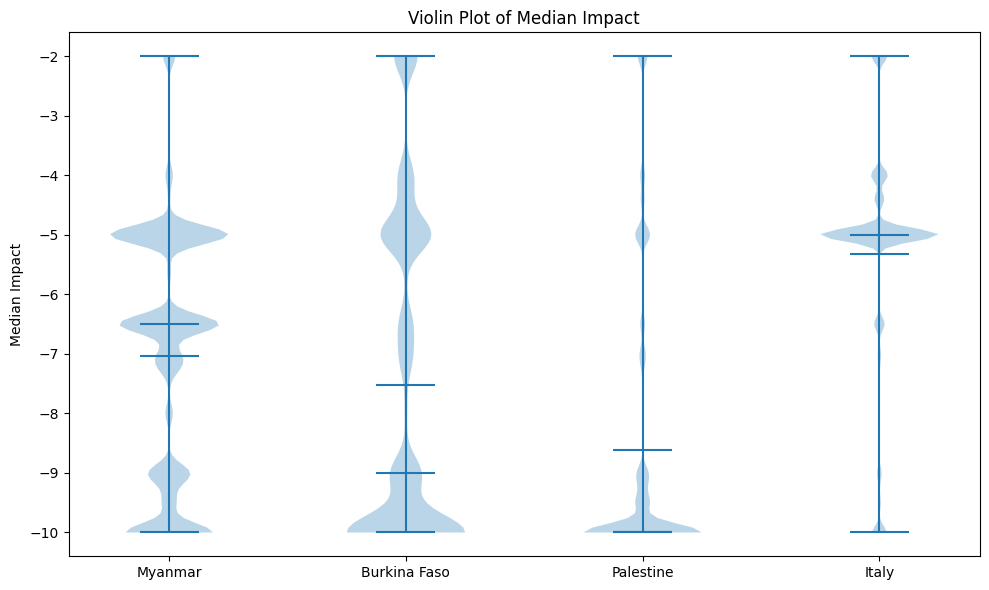

In [105]:
# Violin plots for median_tone and median_impact weighted by mentions_count of Myanmar, Burkina Faso, Palestine, USA
plt.figure(figsize=(10, 6))
# Tone Violin Plot
plt.title('Violin Plot of Median Tone')
plt.ylabel('Median Tone')
plt.violinplot([df_myanmar['median_tone'].repeat(df_myanmar['mentions_count']),
                df_burkina['median_tone'].repeat(df_burkina['mentions_count']),
                df_palestine['median_tone'].repeat(df_palestine['mentions_count']),
                df_italy['median_tone'].repeat(df_italy['mentions_count'])],
                showmeans=True, showmedians=True)
plt.xticks([1, 2, 3, 4], ['Myanmar', 'Burkina Faso', 'Palestine', 'Italy'])
# Impact Violin Plot
plt.figure(figsize=(10, 6))
plt.title('Violin Plot of Median Impact')
plt.ylabel('Median Impact')
plt.violinplot([df_myanmar['median_impact'].repeat(df_myanmar['mentions_count']),
                df_burkina['median_impact'].repeat(df_burkina['mentions_count']),
                df_palestine['median_impact'].repeat(df_palestine['mentions_count']),
                df_italy['median_impact'].repeat(df_italy['mentions_count'])],
                showmeans=True, showmedians=True)
plt.xticks([1, 2, 3, 4], ['Myanmar', 'Burkina Faso', 'Palestine', 'Italy'])
plt.tight_layout()
plt.show()

In [ ]:
# Save processed dataframes to CSV files
processed_path = "../data/processed/"
# Save processed dataframes combined
df_combined = pd.concat([df_myanmar.assign(country='Myanmar'),
                         df_burkina.assign(country='Burkina Faso'),
                         df_palestine.assign(country='Palestine'),
                         df_italy.assign(country='Italy')])
df_tone = df_combined[['country', 'mention_week', 'median_tone', 'mentions_count']]
df_tone = df_tone.rename(columns={'median_tone': 'value'})
df_impact = df_combined[['country', 'mention_week', 'median_impact', 'mentions_count']]
df_impact = df_impact.rename(columns={'median_impact': 'value'})
df_tone.to_csv(processed_path + "violin_plot_tone.csv", index=False)
df_impact.to_csv(processed_path + "violin_plot_impact.csv", index=False)